In [1]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# SOAP feature config
from dscribe.descriptors import SOAP
r_cut = 6
n_max = 12
l_max = 8
sigma = 0.5
rbf = "gto"
average = "inner"


# Clustering & Dimensionality Reduction Numerical Tests

This notebook contains the numerical test used for the software development. The goal here is to first of all test different dimensionality reduction techniques, and try the effect of different features on the clustering results. The clustering results are then evaluated using different metrics

# Water Dimer

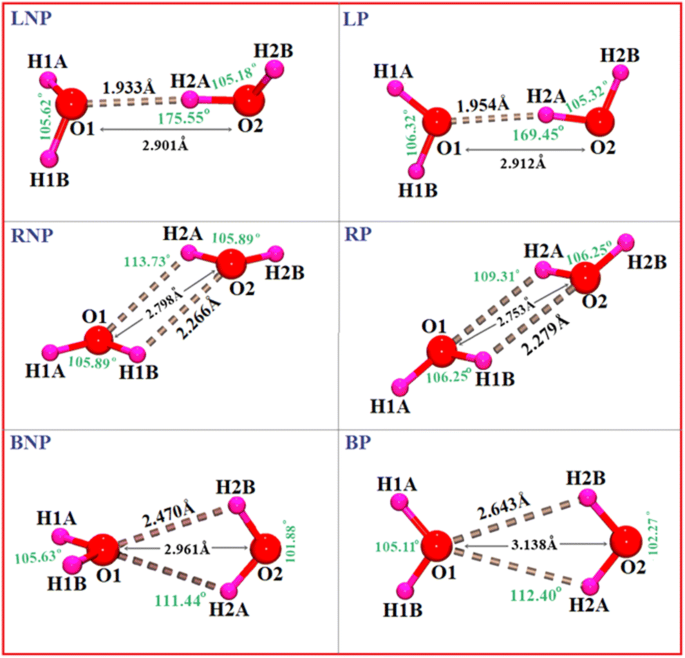

I first consider different conformations of the water dimer. We read in the structures and generate a combined feature matrix using the SOAP descriptor.



In [3]:
h2o_2_1 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_1.xyz")
h2o_2_2 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_2.xyz")
h2o_2_3 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_3.xyz")
h2o_2_4 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_4.xyz")
h2o_2_5 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_5.xyz")

# Find covalent bonds using a simple distance-based criterion
def find_bonds(atoms, cutoff=1.2):
    positions = atoms.get_positions()
    symbols = atoms.get_chemical_symbols()
    bonds = []
    for i in range(len(atoms)):
        for j in range(i + 1, len(atoms)):
            distance = np.linalg.norm(positions[i] - positions[j])
            if distance < cutoff:
                bonds.append((i, j))
    return bonds

print(find_bonds(h2o_2_1))
print(find_bonds(h2o_2_2))
print(find_bonds(h2o_2_3))
print(find_bonds(h2o_2_4))
print(find_bonds(h2o_2_5))


[(0, 1), (0, 2), (3, 4), (3, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]
[(0, 2), (0, 3), (1, 4), (1, 5)]


In [4]:
submol_indices_1 = [[0,1,2], [3,4,5]]
submol_indices_2 = [[0,2,3],[1,4,5]]
submol_indices_3 = [[0,2,3],[1,4,5]]
submol_indices_4 = [[0,2,3],[1,4,5]]
submol_indices_5 = [[0,2,3],[1,4,5]]

+ H2O_2_1 is the global minimum structure
+ H2O_2_2 is the cyclic RP structure
+ H2O_2_3 is the cyclic RNP structure
+ H2O_2_4 is the linear planar structure
+ H2O_2_5 is the BP structure


In [5]:
soap = SOAP(
    species=["H", "O"],
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    sigma=sigma,
    rbf=rbf,
    average=average,
)
feature_matrix = soap.create([h2o_2_1, h2o_2_2, h2o_2_3, h2o_2_4, h2o_2_5])
print(feature_matrix.shape)

(5, 2700)


## Distance in feature space using various metrics

One problem in high dimensional space is always the use of the standard euclidean distance. $L_2$ the problem is that as the number of dimensions increase the distance between points becomes more and more similar. This can be easily be visualized by the following example:

To visualize this we plot both the contrast $D_{max} - D_{min}/D_{min}$ and the Coefficient of Variation $D_{std}/D_{mean}$ as a function of the number of dimensions. 

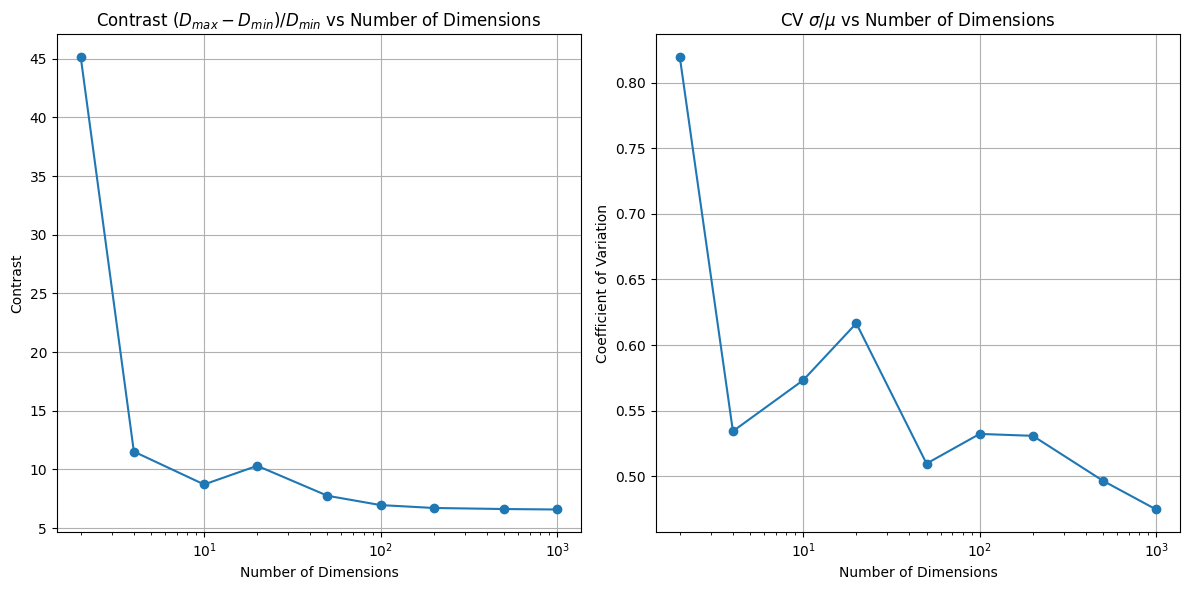

In [6]:
dims = [2, 4, 10, 20, 50, 100, 200, 500, 1000]
results = []
for d in dims:
    # Sample d dimensions from the feature matrix
    sampled_features = feature_matrix[:, :d]
    # Calculate the pairwise distances between the sampled features
    from scipy.spatial.distance import pdist, squareform

    distances = pdist(sampled_features, metric="euclidean")
    distance_matrix = squareform(distances)
    # Calculate the contrast and coefficient of variation
    D_max = np.max(distances)
    D_min = np.min(distances)
    D_mean = np.mean(distances)
    D_std = np.std(distances)
    contrast = (D_max - D_min) / D_min
    coeff_var = D_std / D_mean
    results.append((d, contrast, coeff_var))
# Plot the results
results = np.array(results)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(results[:, 0], results[:, 1], marker="o")
plt.xscale("log")
plt.xlabel("Number of Dimensions")
plt.ylabel("Contrast")
plt.grid()
plt.title("Contrast $(D_{max} - D_{min})/D_{min}$ vs Number of Dimensions")
plt.subplot(1, 2, 2)
plt.plot(results[:, 0], results[:, 2], marker="o")
plt.xscale("log")
plt.grid()
plt.xlabel("Number of Dimensions")
plt.ylabel("Coefficient of Variation")
plt.title("CV $\sigma / \mu$ vs Number of Dimensions")
plt.tight_layout()
plt.show()

Considering both the contrast and the coefficient of variation we can see that as the number of dimensions increase the distance between points becomes more and more similar. This is a problem for clustering algorithms that rely on distance metrics, as it becomes harder to distinguish between different clusters.





We now perform a numerical test to see how the different metrics can distinguish in a high dimensional space

For this we consider the following metrics:


+ Minkowski type: Euclidean/Manhatten/Chebyshev
+ Normalized Spatial Metrics: Mahalanobis
+ Correlation Metrics: Cosine

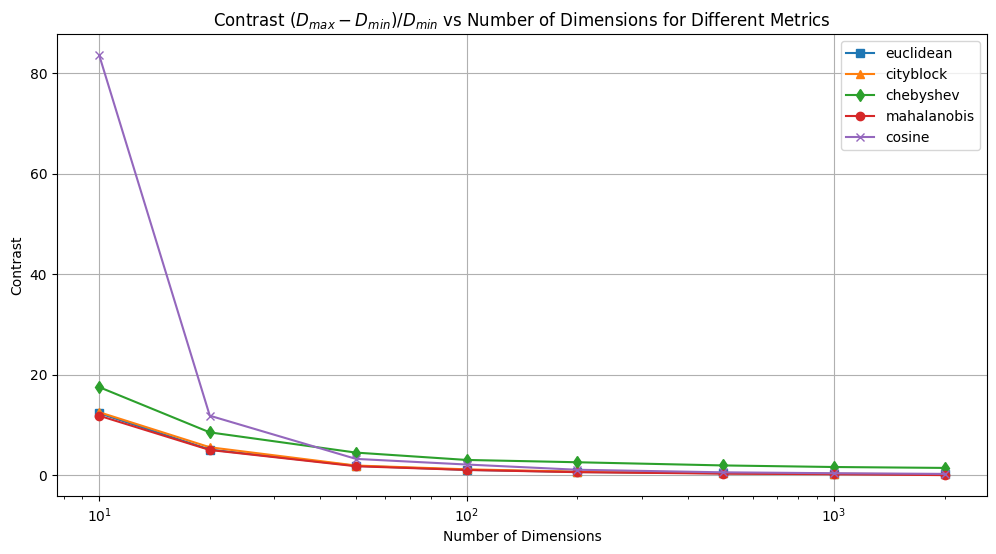

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def compare_metrics(dims=(10,20,50,100, 200, 500,1000,2000), n_samples=2000, random_state=42):
    """  
    For each dimension in 'dims' sample 'n_samples' random points and compute the contrast
    (D_max - D_min) / D_min 

    Use 5000 samples to get a non-singular covariance matrix for the Mahalanobis distance.
    """
    rng = np.random.default_rng(random_state)

    
    metrics = ["euclidean", "cityblock", "chebyshev", "mahalanobis", "cosine"]
    all_results = {metric: [] for metric in metrics}
    for d in dims:
        X = rng.normal(size=(n_samples, d))
        for m in metrics:
            if m == "euclidean":
                distances = pdist(X, metric="euclidean")
            elif m == "cityblock":
                distances = pdist(X, metric="cityblock")
            elif m == "chebyshev":
                distances = pdist(X, metric="chebyshev")
            elif m == "mahalanobis":
                cov = np.cov(X, rowvar=False)
                VI = np.linalg.pinv(cov)
                distances = pdist(X, metric="mahalanobis", VI=VI)
            elif m == "cosine":
                distances = pdist(X, metric="cosine")
            D_max = np.max(distances)
            D_min = np.min(distances)
            contrast = (D_max - D_min) / D_min
            all_results[m].append(contrast)
    plt.figure(figsize=(12, 6))
    for m in metrics:
        if m == "mahalanobis":
            plt.plot(dims, all_results[m], marker="o", label=m)
        elif m == "cosine":
            plt.plot(dims, all_results[m], marker="x", label=m)
        elif m == "euclidean":
            plt.plot(dims, all_results[m], marker="s", label=m)
        elif m == "cityblock":
            plt.plot(dims, all_results[m], marker="^", label=m)
        elif m == "chebyshev":
            plt.plot(dims, all_results[m], marker="d", label=m)

    
    plt.xscale("log")
    plt.xlabel("Number of Dimensions")
    plt.ylabel("Contrast")
    plt.title("Contrast $(D_{max} - D_{min})/D_{min}$ vs Number of Dimensions for Different Metrics")
    plt.grid()
    plt.legend()
    plt.show()  

compare_metrics()
        

# Distance Measurement in Ambient Space

We can test the effect of different metrics on distinguishing different confomers in our ambient space generated by the SOAP descriptor. 


This plot then shows that the contrast is dependent on the underlying metric and thus also the clustering results will be dependent on the underlying metric

KeyError: 'mahalanobis'

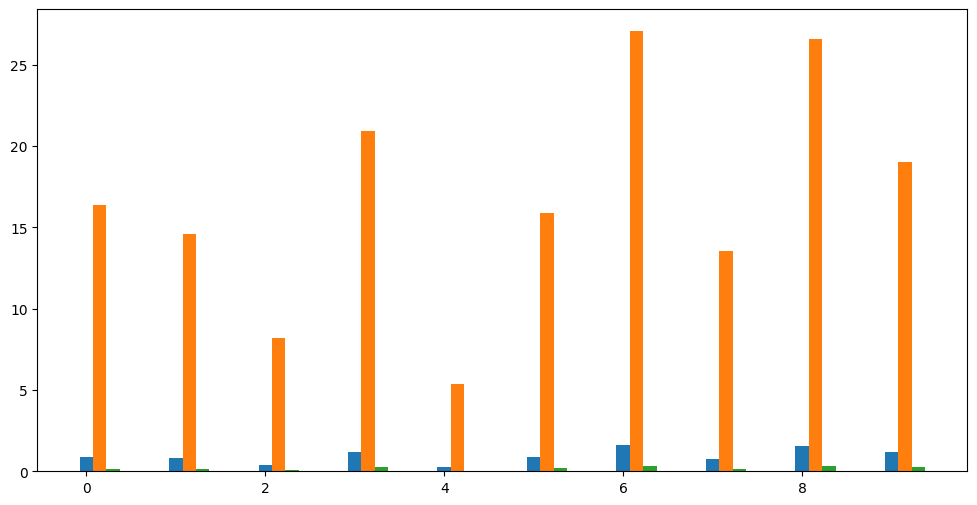

In [8]:
# We test again ["euclidean", "cityblock", "chebyshev", "mahalanobis", "cosine"]
# Now applied to our SOAP feature ambient space
# Compute features of 5 confomers
h2o_2_1_features = soap.create(h2o_2_1)
h2o_2_2_features = soap.create(h2o_2_2)
h2o_2_3_features = soap.create(h2o_2_3)
h2o_2_4_features = soap.create(h2o_2_4)
h2o_2_5_features = soap.create(h2o_2_5)

metrics = ["euclidean", "cityblock", "chebyshev", "mahalanobis", "cosine"]
feature_matrix = np.array([
    h2o_2_1_features,
    h2o_2_2_features,
    h2o_2_3_features,
    h2o_2_4_features,
    h2o_2_5_features,
])
distances = {}
for m in metrics:
    if m == "euclidean":
        distances[m] = pdist(feature_matrix, metric="euclidean")
    elif m == "cityblock":
        distances[m] = pdist(feature_matrix, metric="cityblock")
    elif m == "chebyshev":
        distances[m] = pdist(feature_matrix, metric="chebyshev")
    elif m == "mahalanobis":
        # Problem is that mahalanobis distance results require a non-singular covariance matrix
        cov = np.cov(feature_matrix, rowvar=False)
        VI = np.linalg.pinv(cov)
        distances[m] = pdist(feature_matrix, metric="mahalanobis", VI=VI)
    elif m == "cosine":
        distances[m] = pdist(feature_matrix, metric="cosine")
# remove the mahalanobis distance since it is not reliable with only 5 samples and a high dimensional feature space
distances.pop("mahalanobis")

# Generate Labels of the Type "1-2", "1-3", "1-4", "1-5", "2-3", "2-4", "2-5", "3-4", "3-5", "4-5"
# For the plot we generate a barplot with the relative distances for each metric
labels = ["1-2", "1-3", "1-4", "1-5", "2-3", "2-4", "2-5", "3-4", "3-5", "4-5"]
x = np.arange(len(labels))
width = 0.15
plt.figure(figsize=(12, 6))
for i, m in enumerate(metrics):
    plt.bar(x + i * width, distances[m], width=width, label=m)
plt.xticks(x + width * 2, labels)
plt.xlabel("Conformer Pairs")
plt.ylabel("Distance")
plt.title("Distances Between Conformer Pairs for Different Metrics")
plt.legend()
plt.grid()
plt.show()

### Embedding Test

First we plot this high dimensional feature space in two dimensional embeddings using the following techniques:

+ PCA
+ Kernel-based PCA
+ t-SNE
+ UMAP

Explained variance ratio: [0.771057   0.18422946]


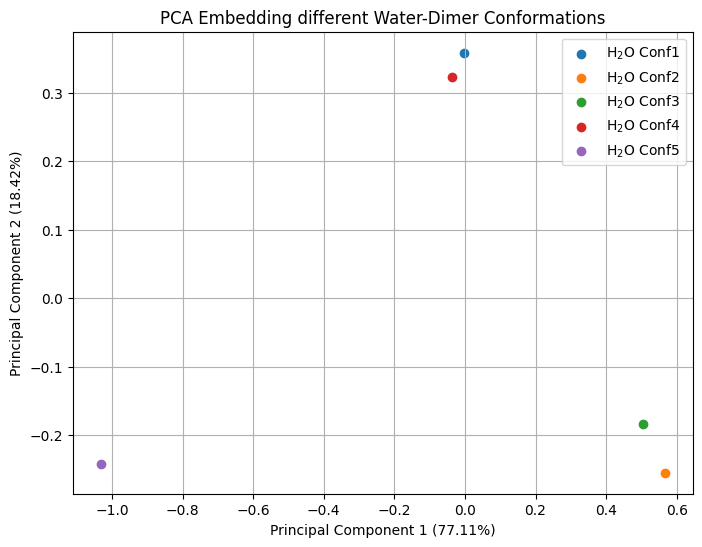

Euclidean distances between the points in the embedding space:
[[0.         0.83734598 0.74310879 0.04814795 1.1908186 ]
 [0.83734598 0.         0.09427964 0.83535068 1.59709361]
 [0.74310879 0.09427964 0.         0.74146188 1.53603446]
 [0.04814795 0.83535068 0.74146188 0.         1.14473966]
 [1.1908186  1.59709361 1.53603446 1.14473966 0.        ]]


In [ ]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
# Get the explained variance and the embedding
embedding = pca.fit_transform(feature_matrix)
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio: {explained_variance_ratio}")
# The sum of the explained variance ratio is equal to 1
# So i multiply it by 100 to get the percentage of variance explained by each component
explained_variance_ratio = explained_variance_ratio * 100
cluster_labels = ["H$_2$O Conf1", "H$_2$O Conf2", "H$_2$O Conf3", "H$_2$O Conf4", "H$_2$O Conf5"]

# Plot the embedding and label the points according to their true labels
plt.figure(figsize=(8, 6))
for i, label in enumerate(cluster_labels):
    plt.scatter(embedding[i, 0], embedding[i, 1], label=label)
plt.xlabel(f"Principal Component 1 ({explained_variance_ratio[0]:.2f}%)")
plt.ylabel(f"Principal Component 2 ({explained_variance_ratio[1]:.2f}%)")
plt.title("PCA Embedding different Water-Dimer Conformations")
plt.legend()
plt.grid()
plt.show()

# Calculate euclidean distance between the points in the embedding space
from scipy.spatial.distance import pdist, squareform
euclidean_distances = squareform(pdist(embedding, metric="euclidean"))
print("Euclidean distances between the points in the embedding space:")
print(euclidean_distances)



This plot makes sense from a chemcial perspective as we expect the global minimum structure and the linear planar structure to cluster together. Also both the cyclic structure show a distinct cluster on this plot. Again one thing to note is that the distance again depends on the dimensionality of the embedded space here in this plot for example Conf1 and Conf4 are very close together if we would run the same analysis with a 3D embedding we would get the following results.

Explained variance ratio: [0.771057   0.18422946 0.03673779]


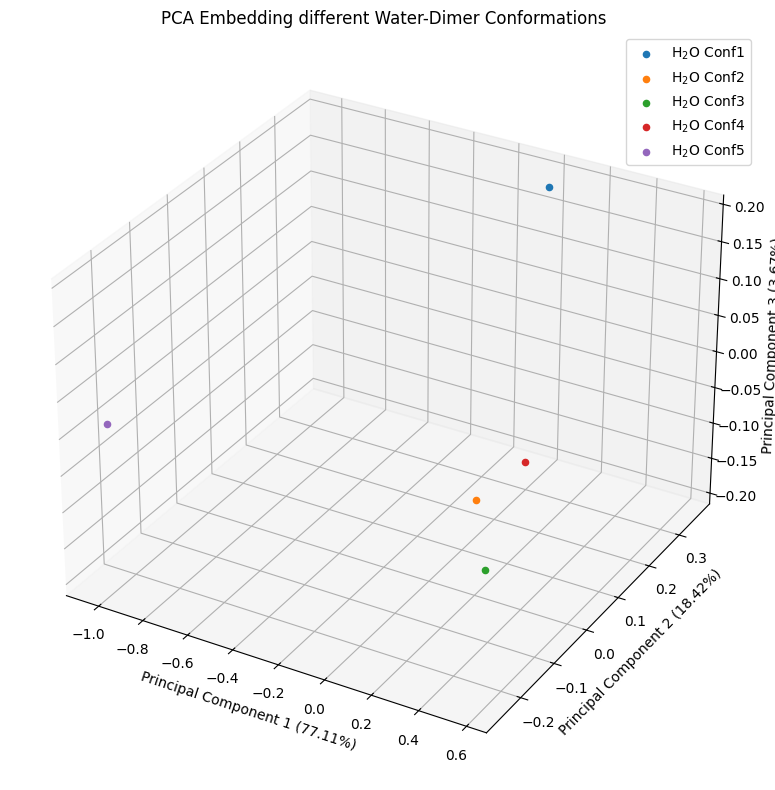

Euclidean distances between the points in the 3D embedding space:
[[0.         0.84626824 0.78463111 0.37629996 1.20395723]
 [0.84626824 0.         0.16002297 0.87214289 1.59803412]
 [0.78463111 0.16002297 0.         0.75132544 1.53783923]
 [0.37629996 0.87214289 0.75132544 0.         1.16136843]
 [1.20395723 1.59803412 1.53783923 1.16136843 0.        ]]


In [ ]:
pca = PCA(n_components=3)
embedding = pca.fit_transform(feature_matrix)
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio: {explained_variance_ratio}")
explained_variance_ratio = explained_variance_ratio * 100
cluster_labels = ["H$_2$O Conf1", "H$_2$O Conf2", "H$_2$O Conf3", "H$_2$O Conf4", "H$_2$O Conf5"]

# Plot 3D embedding
plt.figure(figsize=(12, 8))
ax = plt.axes(projection="3d")
for i, label in enumerate(cluster_labels):
    ax.scatter(embedding[i, 0], embedding[i, 1], embedding[i, 2], label=label)
ax.set_xlabel(f"Principal Component 1 ({explained_variance_ratio[0]:.2f}%)")
ax.set_ylabel(f"Principal Component 2 ({explained_variance_ratio[1]:.2f}%)")
ax.set_zlabel(f"Principal Component 3 ({explained_variance_ratio[2]:.2f}%)")
ax.set_title("PCA Embedding different Water-Dimer Conformations")
ax.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Calculate euclidean distance between the points in the 3D embedding space
euclidean_distances_3d = squareform(pdist(embedding, metric="euclidean"))
print("Euclidean distances between the points in the 3D embedding space:")
print(euclidean_distances_3d)

Explained variance ratio (Kernel PCA): [0.80703933 0.19296067]


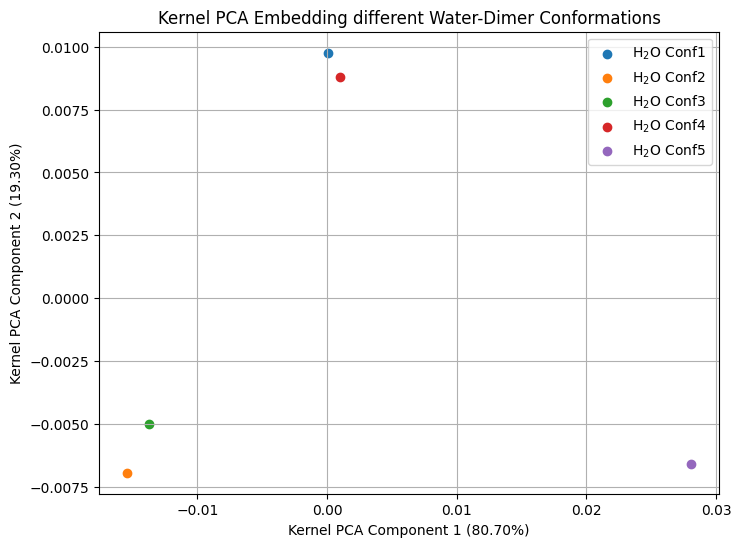

Euclidean distances between the points in the Kernel PCA embedding space:
[[0.         0.02278798 0.02022356 0.00130973 0.03240549]
 [0.02278798 0.         0.0025656  0.02273374 0.04345703]
 [0.02022356 0.0025656  0.         0.02017883 0.04179633]
 [0.00130973 0.02273374 0.02017883 0.         0.0311519 ]
 [0.03240549 0.04345703 0.04179633 0.0311519  0.        ]]


In [ ]:
# Kernel based PCA
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=2, kernel='rbf') # If Gamma is none then it is set to 1/n_features
embedding_kpca = kpca.fit_transform(feature_matrix)
explained_variance_ratio_kpca =  kpca.eigenvalues_ / np.sum(kpca.eigenvalues_)
print(f"Explained variance ratio (Kernel PCA): {explained_variance_ratio_kpca}")
explained_variance_ratio_kpca = explained_variance_ratio_kpca * 100
cluster_labels = ["H$_2$O Conf1", "H$_2$O Conf2", "H$_2$O Conf3", "H$_2$O Conf4", "H$_2$O Conf5"]
# Plot the kernel PCA embedding
plt.figure(figsize=(8, 6))
for i, label in enumerate(cluster_labels):
    plt.scatter(embedding_kpca[i, 0], embedding_kpca[i, 1], label=label)
plt.xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca[0]:.2f}%)")
plt.ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca[1]:.2f}%)")
plt.title("Kernel PCA Embedding different Water-Dimer Conformations")
plt.legend()
plt.grid()
plt.show()

# Calculate euclidean distance between the points in the kernel PCA embedding space
euclidean_distances_kpca = squareform(pdist(embedding_kpca, metric="euclidean"))
print("Euclidean distances between the points in the Kernel PCA embedding space:")
print(euclidean_distances_kpca)

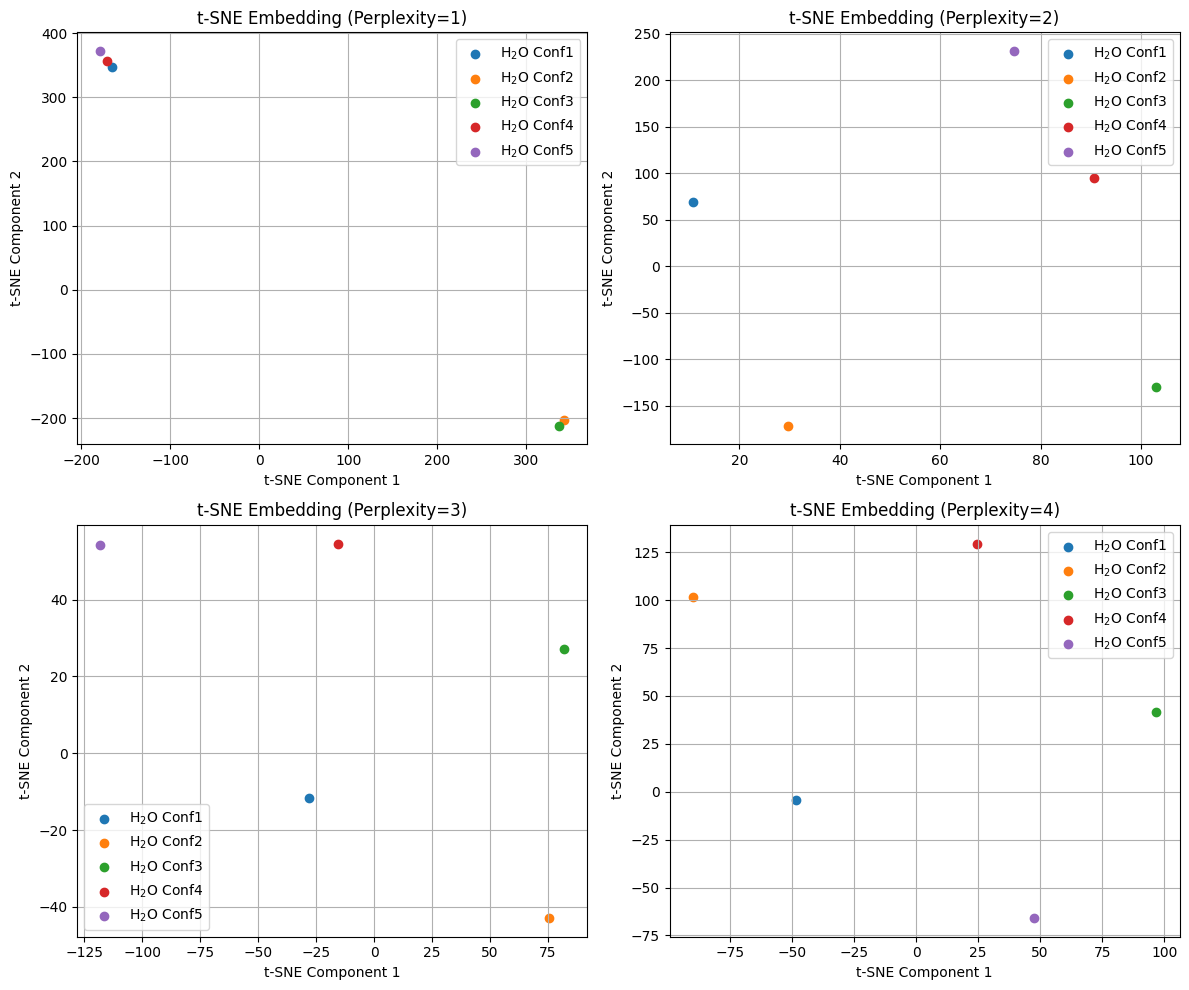

In [ ]:
# t-SNE
from sklearn.manifold import TSNE
perplexity_vals = [1,2,3,4]
# make 4x4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, perplexity in enumerate(perplexity_vals):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    embedding_tsne = tsne.fit_transform(feature_matrix)
    
    ax = axes[i//2, i%2]
    for j, label in enumerate(cluster_labels):
        ax.scatter(embedding_tsne[j, 0], embedding_tsne[j, 1], label=label)
    ax.set_title(f"t-SNE Embedding (Perplexity={perplexity})")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

We can clearly see depending on the **perplexity** hyperparameter we use the embedding space can beutifully separate the different conformations.

The problem with the t-SNE and UMAP plot is that they are highly dependent on the hyperparameters and thus the results can be very different for different runs. In terms of an automated clustering pipeline this is not ideal as we want to have a consistent clustering result. As explained in this paper:

https://arxiv.org/html/2604.22099v1

It is also difficult to run clustering algorithms after doing dimensionality reduction because the feature spaces get distorted and the distance metrics are not preserved. This is especially the case for the t-SNE and the UMAP embeddings.

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fdf9c7a6c40>>
Traceback (most recent call last):
  File "/home/lme/.local/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 

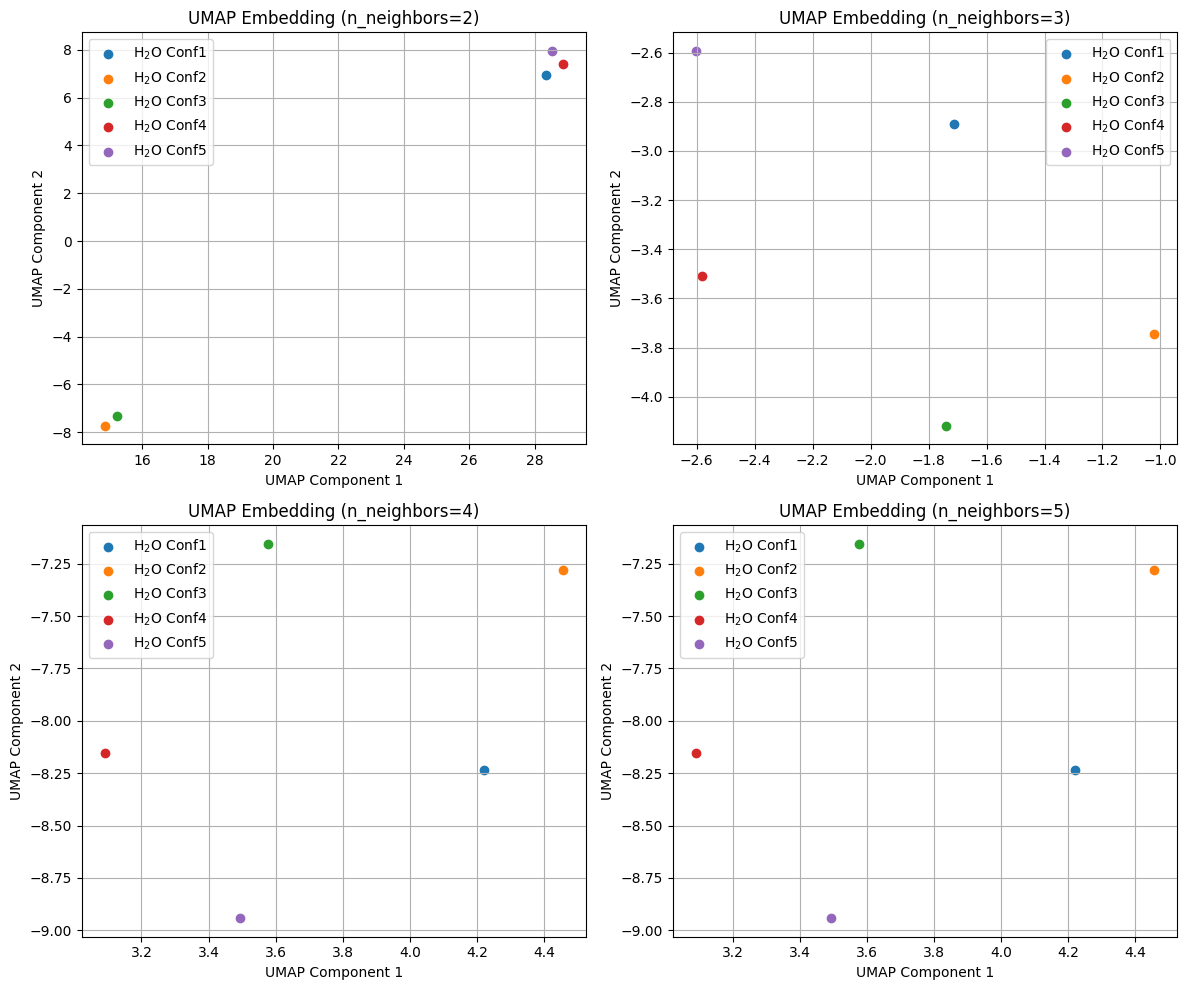

In [ ]:
import umap
n_neighbors_vals = [2,3,4,5]
# make 4x4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, n_neighbors in enumerate(n_neighbors_vals):
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding_umap = reducer.fit_transform(feature_matrix)
    
    ax = axes[i//2, i%2]
    for j, label in enumerate(cluster_labels):
        ax.scatter(embedding_umap[j, 0], embedding_umap[j, 1], label=label)
    ax.set_title(f"UMAP Embedding (n_neighbors={n_neighbors})")
    ax.set_xlabel("UMAP Component 1")
    ax.set_ylabel("UMAP Component 2")
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

## Influence of noise and outliers

Next we do the following:

For each of the 5 conformations we generate 20 random structures by generating small pertubations and applying them to one of the two submolecules of the water dimer. We then label those structures according to the original conformation they come for and generate a new feature matrix for those structures.

In [ ]:

# Original structures and their labels
original_structures = [h2o_2_1, h2o_2_2, h2o_2_3, h2o_2_4, h2o_2_5]
submol_indices = [submol_indices_1, submol_indices_2, submol_indices_3, submol_indices_4, submol_indices_5]
structure_labels = ["H$_2$O Conf1", "H$_2$O Conf2", "H$_2$O Conf3", "H$_2$O Conf4", "H$_2$O Conf5"]

def generate_perturbed_structures_and_features(original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=0.05):
    perturbed_structures = []
    perturbed_labels = []

    for struct_idx, (original_struct, submol_idx, label) in enumerate(zip(original_structures, submol_indices, structure_labels)):
        for pert in range(n_perturbations):
            # Create a copy of the structure
            perturbed_struct = original_struct.copy()
            
            # Randomly choose which submolecule to perturb
            submol_to_perturb = np.random.choice([0, 1])
            indices_to_perturb = submol_idx[submol_to_perturb]
            
            # Generate random perturbations
            positions = perturbed_struct.get_positions()
            # Sample random vector from normal distribution and apply the perturbation scale
            random_displacement = np.random.randn(len(indices_to_perturb), 3) * perturbation_scale
            
            # Apply perturbations to selected submolecule
            # This preserves the internal structure of the submolecule while introducing noise to the overall structure
            for i, atom_idx in enumerate(indices_to_perturb):
                positions[atom_idx] += random_displacement[i]
            
            perturbed_struct.set_positions(positions)
            perturbed_structures.append(perturbed_struct)
            perturbed_labels.append(label)

    # Generate SOAP features for all perturbed structures
    perturbed_feature_matrix = soap.create(perturbed_structures)
    
    return perturbed_structures, perturbed_labels, perturbed_feature_matrix

We now generate 20 pertubations for each conformation and apply the pertubation levels $p \in \{0.01, 0.05, 0.08, 0.1\}$ to the structures. We first test the embedding by using the PCA 

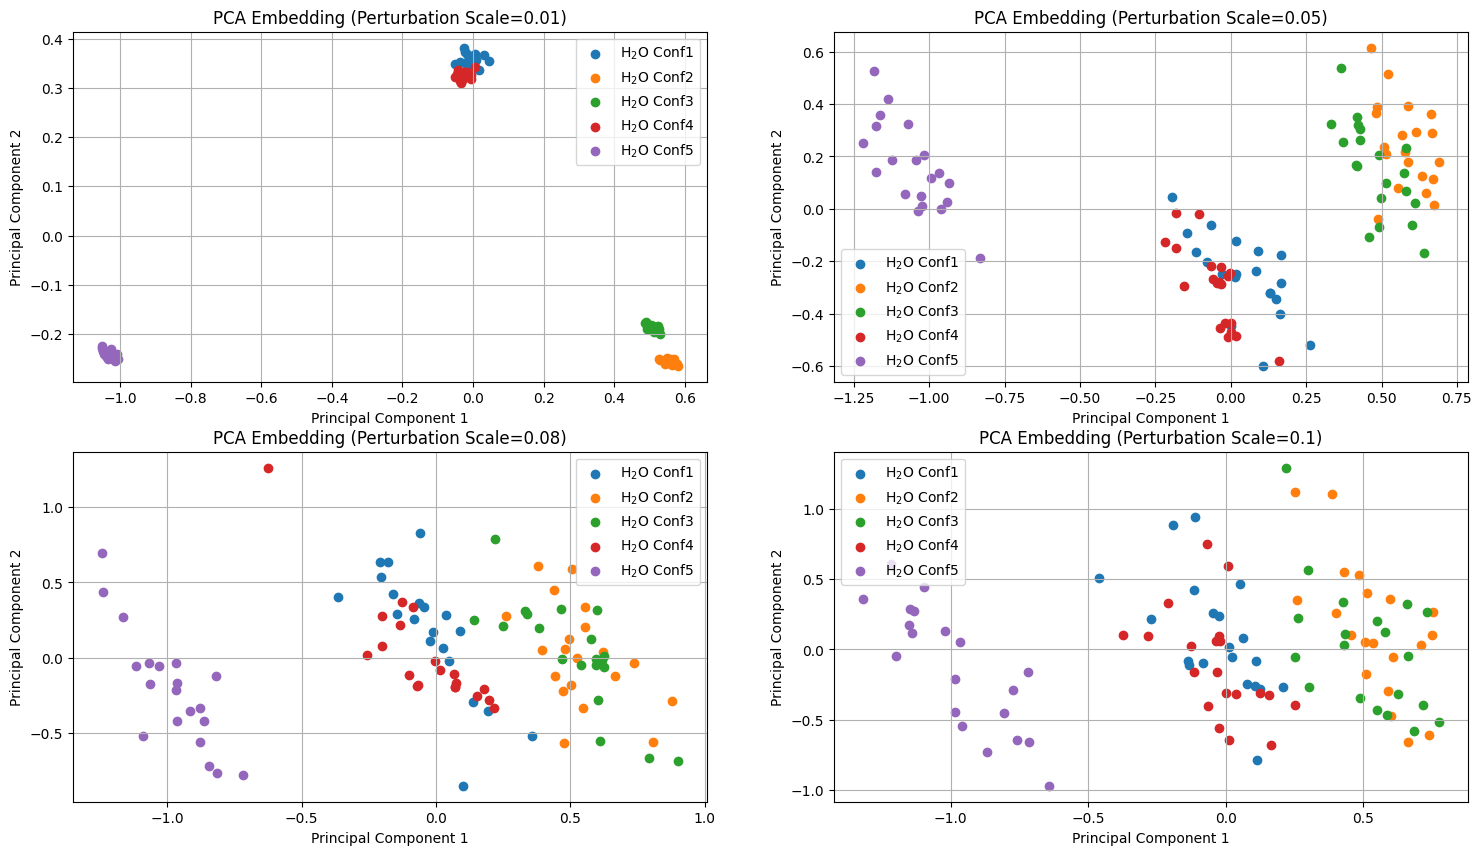

In [ ]:
p = [0.01, 0.05, 0.08, 0.1]
# generate perturbed structures, then pca then 4x4 subplots for the different perturbation levels
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i, perturbation_scale in enumerate(p):
    perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(
        original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=perturbation_scale
    )
    
    # PCA on the perturbed feature matrix
    pca = PCA(n_components=2)
    embedding_perturbed = pca.fit_transform(perturbed_feature_matrix)
    
    ax = axes[i//2, i%2]
    for j, label in enumerate(structure_labels):
        # Get indices of perturbed structures corresponding to this label
        indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
        ax.scatter(embedding_perturbed[indices, 0], embedding_perturbed[indices, 1], label=label)
    
    ax.set_title(f"PCA Embedding (Perturbation Scale={perturbation_scale})")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    # Legend outside the plot
    ax.legend(loc='best')
    ax.grid()

THis plot shows that based on the pertubation level we apply do the structures this 2D embeddind more and more loses the ability to separate the different conformations.

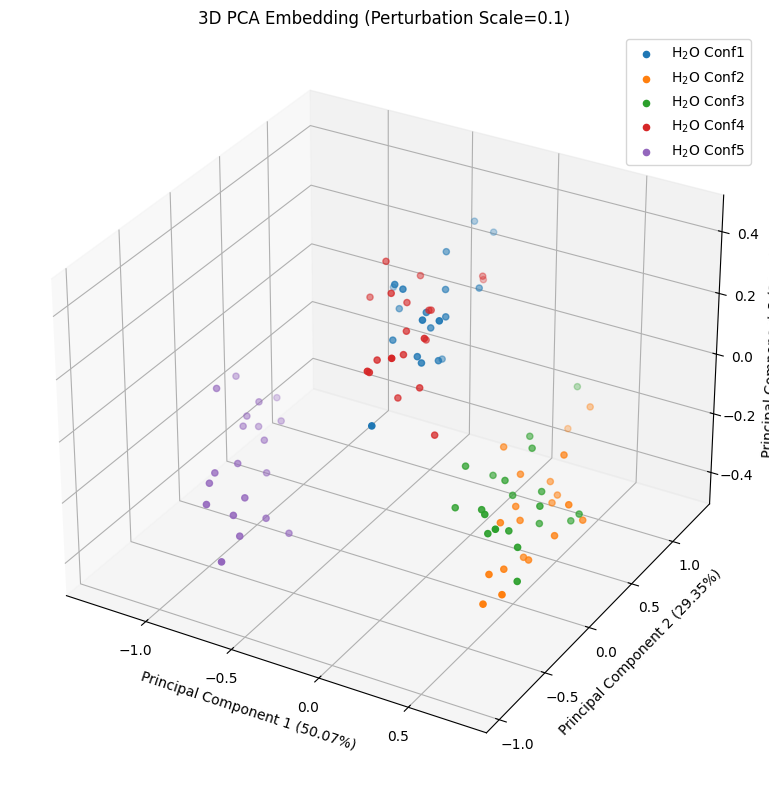

In [ ]:
# 3D PCA embedding for the highest perturbation level
pca_3d = PCA(n_components=3)
embedding_perturbed_3d = pca_3d.fit_transform(perturbed_feature_matrix)
explained_variance_ratio_3d = pca_3d.explained_variance_ratio_ * 100
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for j, label in enumerate(structure_labels):
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_perturbed_3d[indices, 0], embedding_perturbed_3d[indices, 1], embedding_perturbed_3d[indices, 2], label=label)
ax.set_xlabel(f"Principal Component 1 ({explained_variance_ratio_3d[0]:.2f}%)")
ax.set_ylabel(f"Principal Component 2 ({explained_variance_ratio_3d[1]:.2f}%)")
ax.set_zlabel(f"Principal Component 3 ({explained_variance_ratio_3d[2]:.2f}%)")
ax.set_title("3D PCA Embedding (Perturbation Scale=0.1)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

if we again consider the 3D embedding we see that this separation gets a little better. This demonstrates that in the final algorithm we should not only consider a 2D embedding but go for example in terms of PCA to a reasonable amount of explained variance.

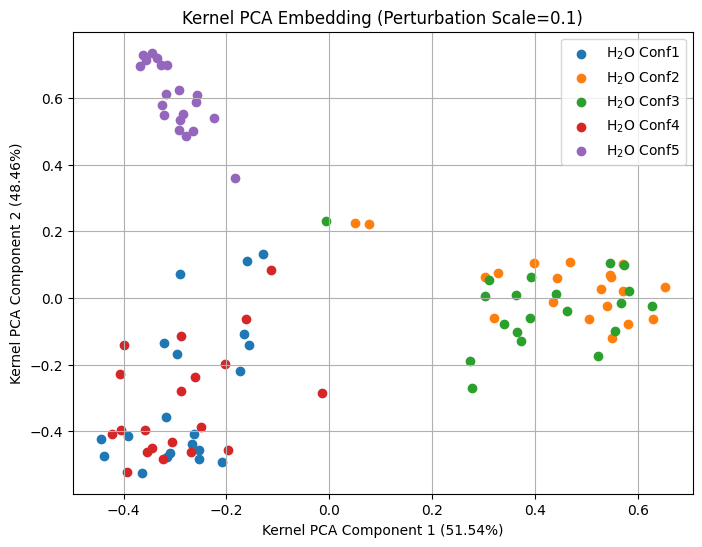

In [ ]:
# Kernel PCA on the perturbed feature matrix
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=2) 
embedding_kpca_perturbed = kpca.fit_transform(perturbed_feature_matrix)
explained_variance_ratio_kpca_perturbed = kpca.eigenvalues_ / np.sum(kpca.eigenvalues_) * 100
fig, ax = plt.subplots(figsize=(8, 6))
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_perturbed[indices, 0], embedding_kpca_perturbed[indices, 1], label=label)
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_perturbed[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_perturbed[1]:.2f}%)")
ax.set_title("Kernel PCA Embedding (Perturbation Scale=0.1)")
ax.legend()
ax.grid()
plt.show()

Kernel-Based PCA is here quite good the only thing is that the kernel has to be chosen carefully. Here for example with a $\gamma$ value of about 1 we get very separated results even in two dimensions.

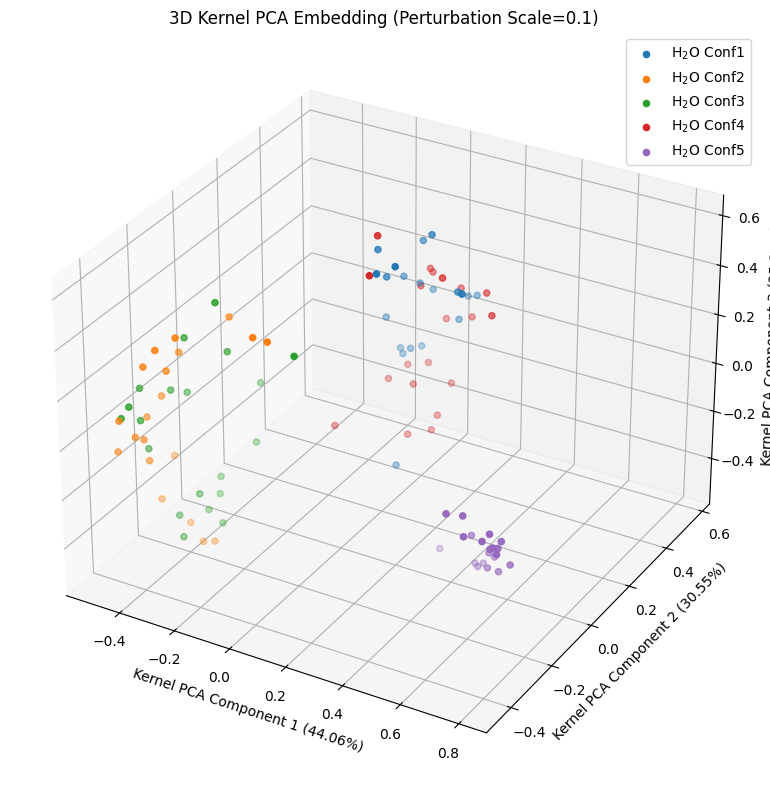

In [ ]:
# Kernel Based PCA 3 DImensions
kpca_3d = KernelPCA(n_components=3, kernel='rbf', gamma=1) 
embedding_kpca_perturbed_3d = kpca_3d.fit_transform(perturbed_feature_matrix)
explained_variance_ratio_kpca_perturbed_3d = kpca_3d.eigenvalues_ / np.sum(kpca_3d.eigenvalues_) * 100
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_perturbed_3d[indices, 0], embedding_kpca_perturbed_3d[indices, 1], embedding_kpca_perturbed_3d[indices, 2], label=label)
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_perturbed_3d[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_perturbed_3d[1]:.2f}%)")
ax.set_zlabel(f"Kernel PCA Component 3 ({explained_variance_ratio_kpca_perturbed_3d[2]:.2f}%)")
ax.set_title("3D Kernel PCA Embedding (Perturbation Scale=0.1)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

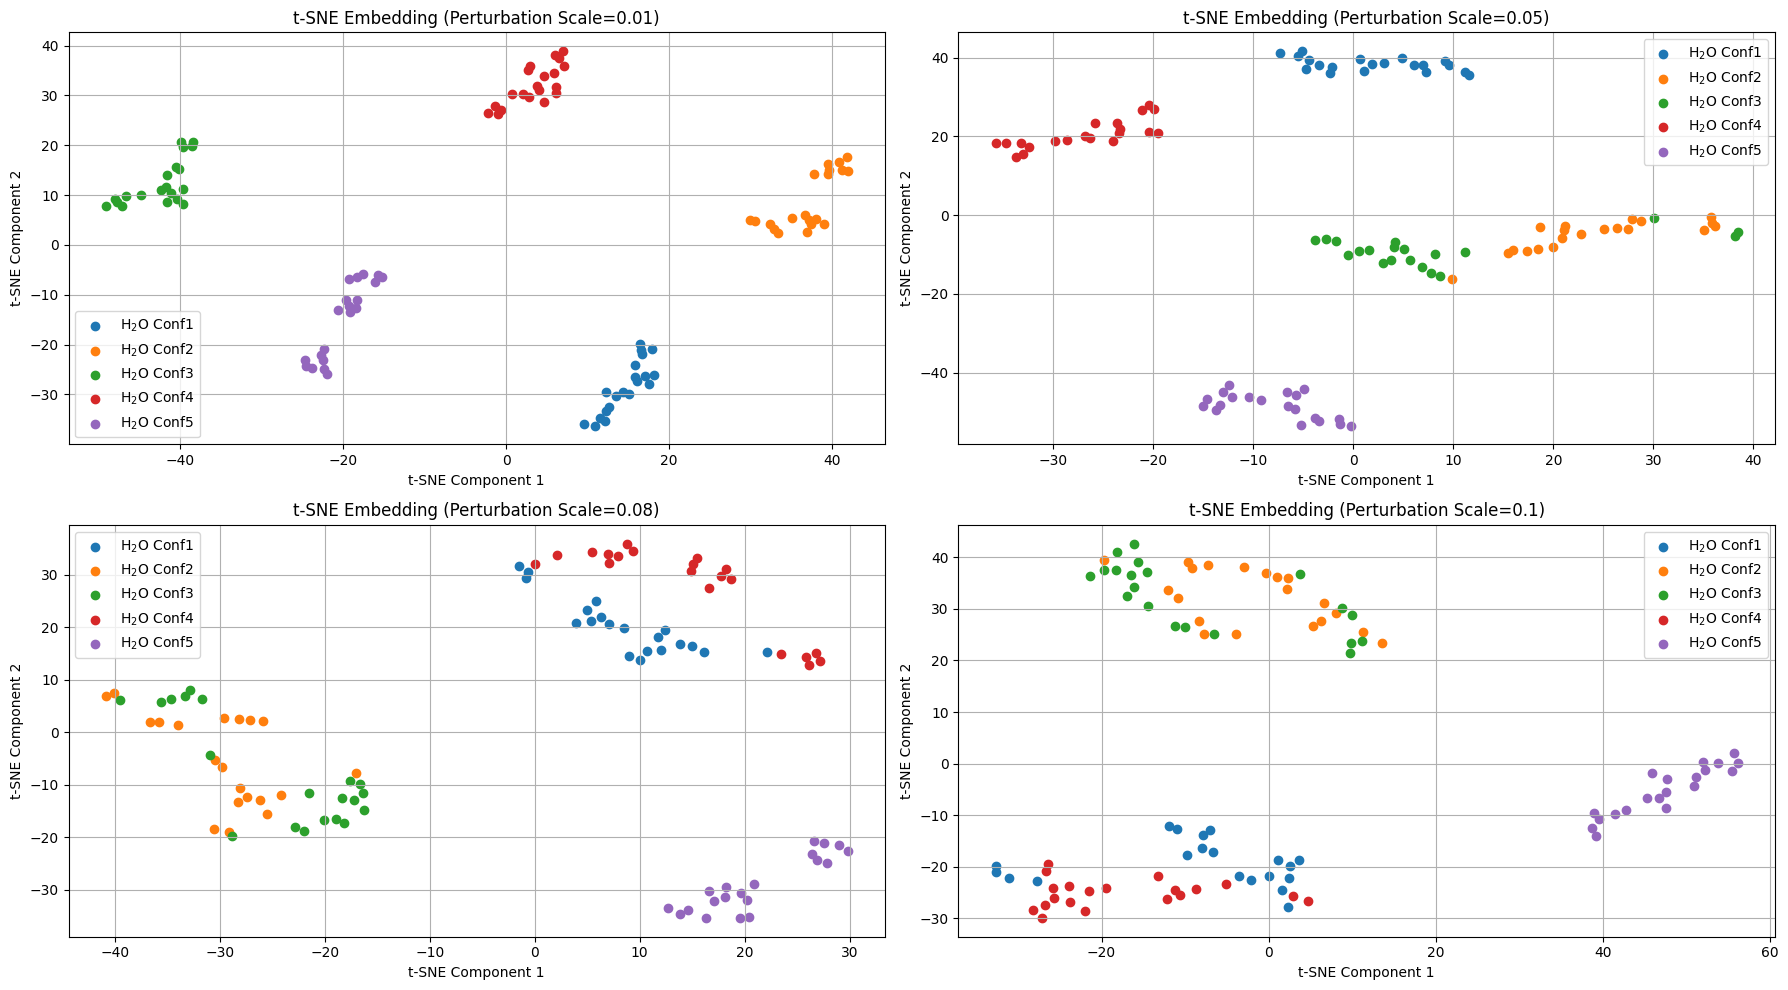

In [ ]:
# t-SNE for different perturbation levels
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i, perturbation_scale in enumerate(p):
    perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(
        original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=perturbation_scale
    )
    
    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    embedding_tsne_perturbed = tsne.fit_transform(perturbed_feature_matrix)
    
    ax = axes[i//2, i%2]
    for j, label in enumerate(structure_labels):
        indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
        ax.scatter(embedding_tsne_perturbed[indices, 0], embedding_tsne_perturbed[indices, 1], label=label)
    
    ax.set_title(f"t-SNE Embedding (Perturbation Scale={perturbation_scale})")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.legend(loc='best')
    ax.grid()
plt.tight_layout()
plt.show()

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


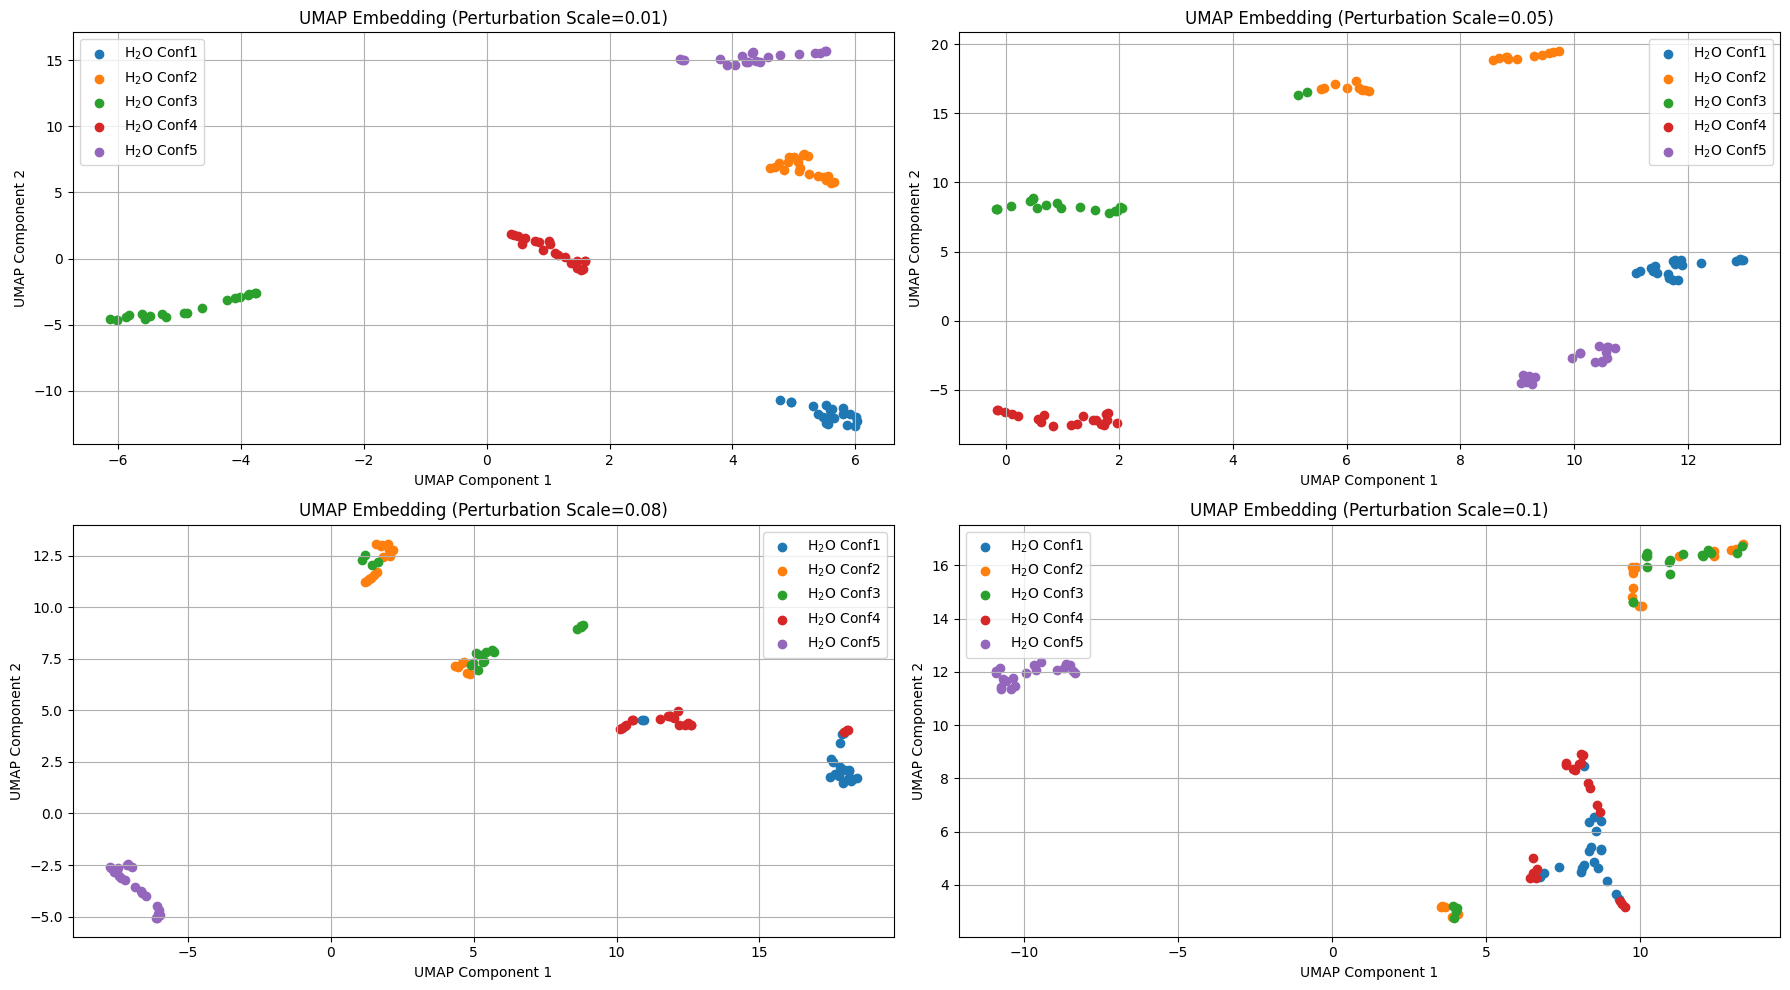

In [ ]:
# UMAP
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for i, perturbation_scale in enumerate(p):
    perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(
        original_structures, submol_indices, structure_labels, n_perturbations=20, perturbation_scale=perturbation_scale
    )
    
    reducer = umap.UMAP(n_neighbors=5, random_state=42)
    embedding_umap_perturbed = reducer.fit_transform(perturbed_feature_matrix)
    
    ax = axes[i//2, i%2]
    for j, label in enumerate(structure_labels):
        indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
        ax.scatter(embedding_umap_perturbed[indices, 0], embedding_umap_perturbed[indices, 1], label=label)
    
    ax.set_title(f"UMAP Embedding (Perturbation Scale={perturbation_scale})")
    ax.set_xlabel("UMAP Component 1")
    ax.set_ylabel("UMAP Component 2")
    ax.legend(loc='best')
    ax.grid()
plt.tight_layout()
plt.show()

The UMAP and the t-SNE embedding are still able to separate the different conformations even at a higher pertubation level. This of course shows the ability of our feature space to seperate the different conformations even in the presence of noise.

## The test dataset:

For the test dataset for each conformers we generate 500 perturbations with a pertubation level of 0.7. This means we get 2500 structures in total. To introduce artificial noise we also add 100 random structures into this dataset. This means we have a total of 2600 structures in our test dataset.

In [ ]:
# Generate the 2500 perturbed structures with a perturbation level of 0.05
perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(
    original_structures, submol_indices, structure_labels, n_perturbations=500, perturbation_scale=0.01
)



## Algorithm 1

This is the first clustering pipeline to obtain appropiate cluster conformations. Here of corse the idea is to apply this Algorithm and then evaluate the results using different clustering metrics as our structures are labeled alread

1. Generate Feature Matrix for the given structures
2. Normalize the Feature Matrix
3. Use Spearman Correlation to filter out highly correlated features with a threshold of 0.9
4. Use Kernel Based PCA to reduce the dimensionality of the feature space to a reasonable amount of explained variance (for example 90\%)
5. Use DBSCAN to cluster the structures in the reduced feature space

In [ ]:
# Normalize Feature Matrix
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_feature_matrix = scaler.fit_transform(perturbed_feature_matrix)
# Apply Spearman Correlation to filter out highly correlated features with a threshold of 0.9 -> use pandas
import pandas as pd
feature_df = pd.DataFrame(normalized_feature_matrix)
corr_matrix = feature_df.corr(method='spearman').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
filtered_feature_matrix = feature_df.drop(columns=to_drop).values
print(f"Original number of features: {normalized_feature_matrix.shape[1]}")
print(f"Number of features after Spearman correlation filtering: {filtered_feature_matrix.shape[1]}")

Original number of features: 2700
Number of features after Spearman correlation filtering: 66


We now perform this kernel PCA 3 Times in the 3 Dimensional Space first on the original unnormalized feature space, then on the normalized feature space and finally on the feature space after filtering out highly correlated features. The results are shown in the following plot.

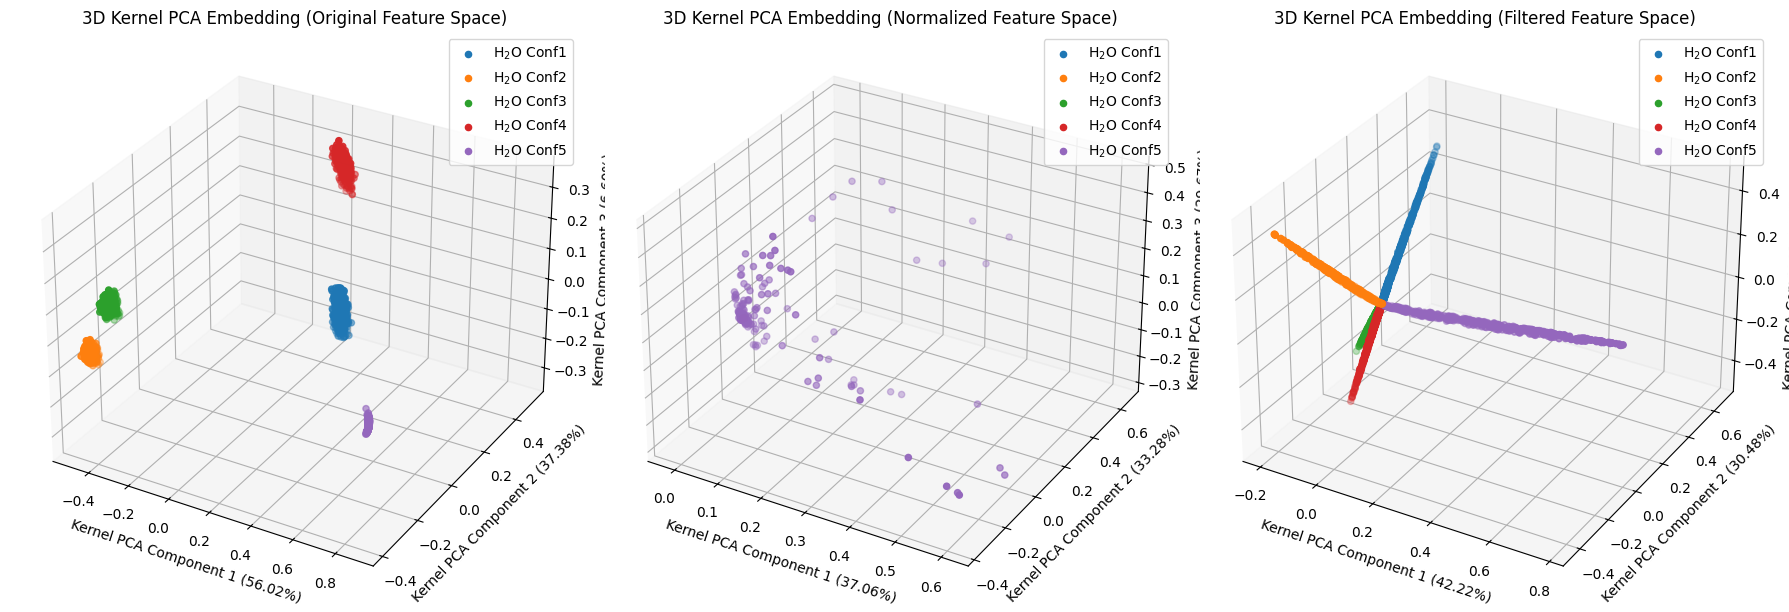

In [ ]:
# Kernel based PCA side by side 3 dimensions for the original, normalized and filtered feature space
fig = plt.figure(figsize=(18, 6))
# Original feature space
kpca_original = KernelPCA(n_components=3, kernel='rbf', gamma=1)
embedding_kpca_original = kpca_original.fit_transform(perturbed_feature_matrix)
explained_variance_ratio_kpca_original = kpca_original.eigenvalues_ / np.sum(kpca_original.eigenvalues_) * 100
ax = fig.add_subplot(131, projection='3d')
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_original[indices, 0], embedding_kpca_original[indices, 1], embedding_kpca_original[indices, 2], label=label)  
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_original[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_original[1]:.2f}%)")
ax.set_zlabel(f"Kernel PCA Component 3 ({explained_variance_ratio_kpca_original[2]:.2f}%)")
ax.set_title("3D Kernel PCA Embedding (Original Feature Space)")
ax.legend()
ax.grid()
# Normalized feature space
kpca_normalized = KernelPCA(n_components=3, kernel='rbf', gamma=1)
embedding_kpca_normalized = kpca_normalized.fit_transform(normalized_feature_matrix)
explained_variance_ratio_kpca_normalized = kpca_normalized.eigenvalues_ / np.sum(kpca_normalized.eigenvalues_) * 100
ax = fig.add_subplot(132, projection='3d')
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_normalized[indices, 0], embedding_kpca_normalized[indices, 1], embedding_kpca_normalized[indices, 2], label=label)
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_normalized[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_normalized[1]:.2f}%)")
ax.set_zlabel(f"Kernel PCA Component 3 ({explained_variance_ratio_kpca_normalized[2]:.2f}%)")
ax.set_title("3D Kernel PCA Embedding (Normalized Feature Space)")
ax.legend()
ax.grid()
# Filtered feature space
kpca_filtered = KernelPCA(n_components=3, kernel='rbf', gamma=1)
embedding_kpca_filtered = kpca_filtered.fit_transform(filtered_feature_matrix)
explained_variance_ratio_kpca_filtered = kpca_filtered.eigenvalues_ / np.sum(kpca_filtered.eigenvalues_) * 100
ax = fig.add_subplot(133, projection='3d')
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_filtered[indices, 0], embedding_kpca_filtered[indices, 1], embedding_kpca_filtered[indices, 2], label=label)
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_filtered[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_filtered[1]:.2f}%)")
ax.set_zlabel(f"Kernel PCA Component 3 ({explained_variance_ratio_kpca_filtered[2]:.2f}%)")
ax.set_title("3D Kernel PCA Embedding (Filtered Feature Space)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

Ok this is definetly a problem considering this soap features, i already average in the feature genration if i then do the Normalization of the Feature matrix again i introduce artificial correlations into the feature space. This is something i have to be very careful about in the original algorithm. Lets try this again but now without the normalization step

Original number of features (raw): 2700
Number of features after Spearman correlation filtering (raw): 66


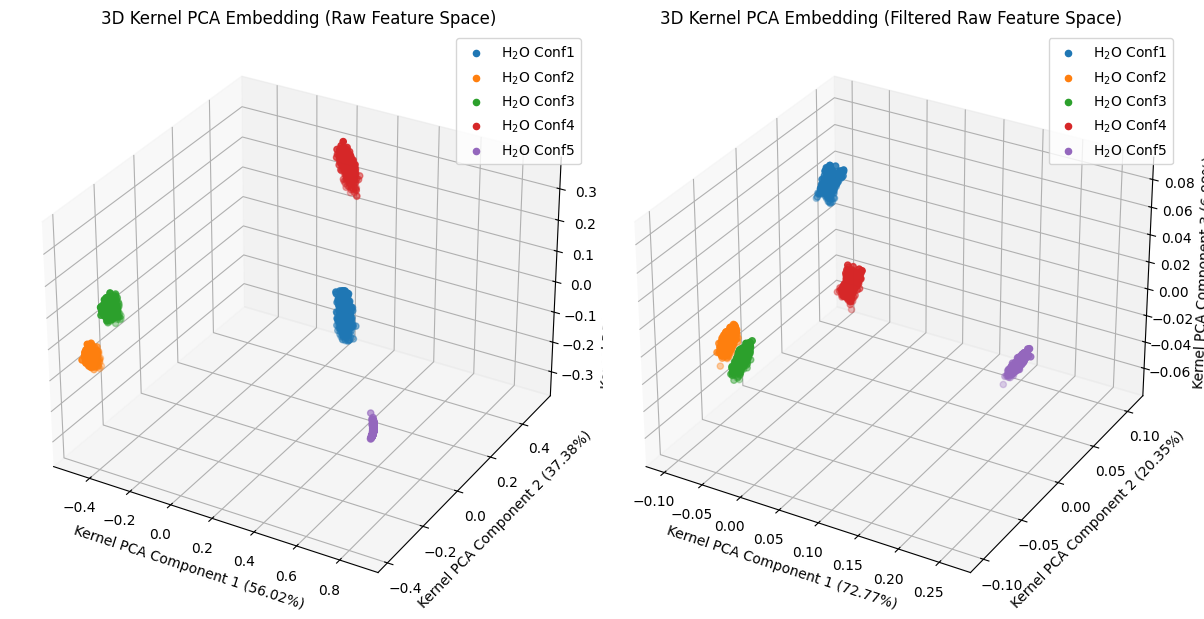

In [ ]:
# Apply Spearman filtering to the original unnormalized feature matrix and plot kernel based PCA in 3 Dimensions for the RAW data and the filtered data
feature_df_raw = pd.DataFrame(perturbed_feature_matrix)
corr_matrix_raw = feature_df_raw.corr(method='spearman').abs()
upper_tri_raw = corr_matrix_raw.where(np.triu(np.ones(corr_matrix_raw.shape), k=1).astype(bool))
to_drop_raw = [column for column in upper_tri_raw.columns if any(upper_tri_raw[column] > 0.9)]
filtered_feature_matrix_raw = feature_df_raw.drop(columns=to_drop_raw).values
print(f"Original number of features (raw): {perturbed_feature_matrix.shape[1]}")
print(f"Number of features after Spearman correlation filtering (raw): {filtered_feature_matrix_raw.shape[1]}")

# Kernel PCA on the raw feature matrix
kpca_raw = KernelPCA(n_components=3, kernel='rbf', gamma=1)
embedding_kpca_raw = kpca_raw.fit_transform(perturbed_feature_matrix)
explained_variance_ratio_kpca_raw = kpca_raw.eigenvalues_ / np.sum(kpca_raw.eigenvalues_) * 100
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(121, projection='3d')
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_raw[indices, 0], embedding_kpca_raw[indices, 1], embedding_kpca_raw[indices, 2], label=label)
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_raw[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_raw[1]:.2f}%)")
ax.set_zlabel(f"Kernel PCA Component 3 ({explained_variance_ratio_kpca_raw[2]:.2f}%)")
ax.set_title("3D Kernel PCA Embedding (Raw Feature Space)")
ax.legend()
ax.grid()
# Kernel PCA on the filtered raw feature matrix
kpca_filtered_raw = KernelPCA(n_components=3, kernel='rbf', gamma=1)
embedding_kpca_filtered_raw = kpca_filtered_raw.fit_transform(filtered_feature_matrix_raw)
explained_variance_ratio_kpca_filtered_raw = kpca_filtered_raw.eigenvalues_ / np.sum(kpca_filtered_raw.eigenvalues_) * 100
ax = fig.add_subplot(122, projection='3d')
for j, label in enumerate(structure_labels):   
    indices = [idx for idx, lbl in enumerate(perturbed_labels) if lbl == label]
    ax.scatter(embedding_kpca_filtered_raw[indices, 0], embedding_kpca_filtered_raw[indices, 1], embedding_kpca_filtered_raw[indices, 2], label=label)
ax.set_xlabel(f"Kernel PCA Component 1 ({explained_variance_ratio_kpca_filtered_raw[0]:.2f}%)")
ax.set_ylabel(f"Kernel PCA Component 2 ({explained_variance_ratio_kpca_filtered_raw[1]:.2f}%)")
ax.set_zlabel(f"Kernel PCA Component 3 ({explained_variance_ratio_kpca_filtered_raw[2]:.2f}%)")
ax.set_title("3D Kernel PCA Embedding (Filtered Raw Feature Space)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

This looks much better thank god. Ok so i think now i should use a much nicer test dataset to do this analysis again. We will generate for each confomer 500 pertubations with a noise level of 0.08 and then add 100 random structures to this dataset. This should give us a good test dataset to evaluate the clustering results on.

In [ ]:
# generate 500 pertrubed structures with noise level of 0.08
perturbed_structures, perturbed_labels, perturbed_feature_matrix = generate_perturbed_structures_and_features(
    original_structures, submol_indices, structure_labels, n_perturbations=100, perturbation_scale=0.08
)

# Generate 100 random structures with a displacement of 0.1 from the original structures to act as outliers
def generate_outliers(original_structures, n_outliers=100, displacement=0.1):
    outlier_structures = []
    outlier_labels = []
    for struct_idx, original_struct in enumerate(original_structures):
        for _ in range(n_outliers // len(original_structures)):
            outlier_struct = original_struct.copy()
            positions = outlier_struct.get_positions()
            random_displacement = np.random.randn(*positions.shape) * displacement
            positions += random_displacement
            outlier_struct.set_positions(positions)
            outlier_structures.append(outlier_struct)
            # Make all into one outlier class
            outlier_labels.append("Outlier")
    return outlier_structures, outlier_labels

outlier_structures, outlier_labels = generate_outliers(original_structures, n_outliers=100, displacement=0.5)
# Combine perturbed structures and outliers
all_structures = perturbed_structures + outlier_structures
all_labels = perturbed_labels + outlier_labels
# Generate SOAP features for all structures
all_feature_matrix = soap.create(all_structures)

Original number of features (all): 2700
Number of features after Spearman correlation filtering (all): 661
Number of components to retain 90% variance: 11


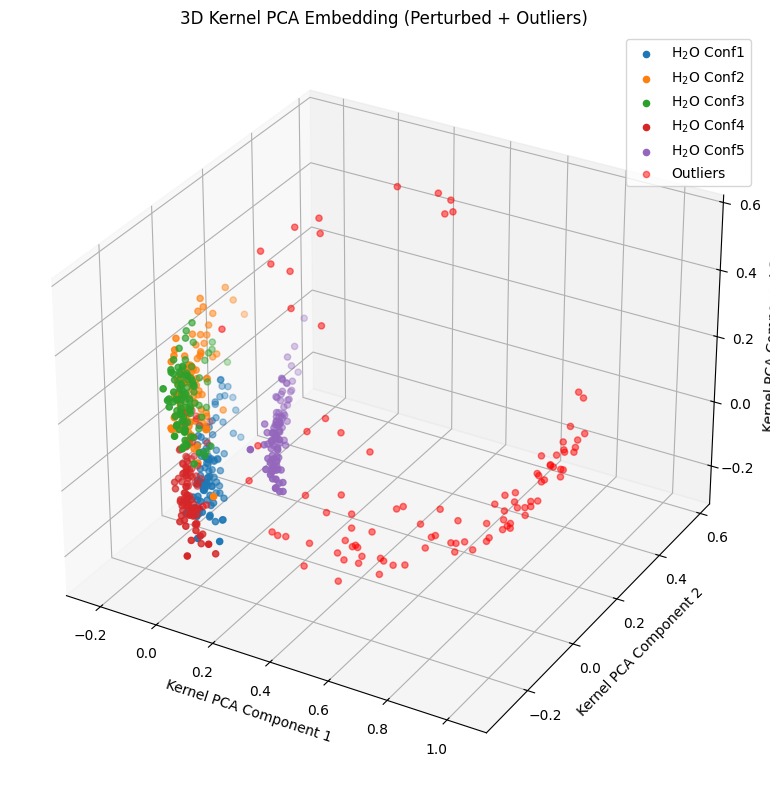

In [ ]:
# Apply spearman correlation filtering to the combined feature matrix then make a kernel based PCA retaining 90 % of the variance and plot the 3D embedding
feature_df_all = pd.DataFrame(all_feature_matrix)
corr_matrix_all = feature_df_all.corr(method='spearman').abs()
upper_tri_all = corr_matrix_all.where(np.triu(np.ones(corr_matrix_all.shape), k=1).astype(bool))
to_drop_all = [column for column in upper_tri_all.columns if any(upper_tri_all[column] > 0.9)]
filtered_feature_matrix_all = feature_df_all.drop(columns=to_drop_all).values
print(f"Original number of features (all): {all_feature_matrix.shape[1]}")
print(f"Number of features after Spearman correlation filtering (all): {filtered_feature_matrix_all.shape[1]}")
# Kernel Based PCA with a lot of components to retain 90% of the variance
kpca_all = KernelPCA(n_components=None, kernel='rbf', gamma=1)
embedding_kpca_all = kpca_all.fit_transform(filtered_feature_matrix_all)
explained_variance_ratio_kpca_all = kpca_all.eigenvalues_ / np.sum(kpca_all.eigenvalues_)
cumulative_variance = np.cumsum(explained_variance_ratio_kpca_all)
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Number of components to retain 90% variance: {n_components_90}")
# Plot the 3D embedding using the first 3 components
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for j, label in enumerate(structure_labels + outlier_labels):   
    indices = [idx for idx, lbl in enumerate(all_labels) if lbl == label]
    if label != "Outlier":
        ax.scatter(embedding_kpca_all[indices, 0], embedding_kpca_all[indices, 1], embedding_kpca_all[indices, 2], label=label)
# Plot all outliers now as one red point
outlier_indices = [idx for idx, lbl in enumerate(all_labels) if lbl == "Outlier"]
ax.scatter(embedding_kpca_all[outlier_indices, 0], embedding_kpca_all[outlier_indices, 1], embedding_kpca_all[outlier_indices, 2], label="Outliers", color='red', alpha=0.5)
ax.set_xlabel("Kernel PCA Component 1")
ax.set_ylabel("Kernel PCA Component 2") 
ax.set_zlabel("Kernel PCA Component 3")
ax.set_title("3D Kernel PCA Embedding (Perturbed + Outliers)")
ax.legend(loc='best')
ax.grid()
plt.tight_layout()
plt.show()

Number of inliers detected: 561
Number of outliers detected: 39


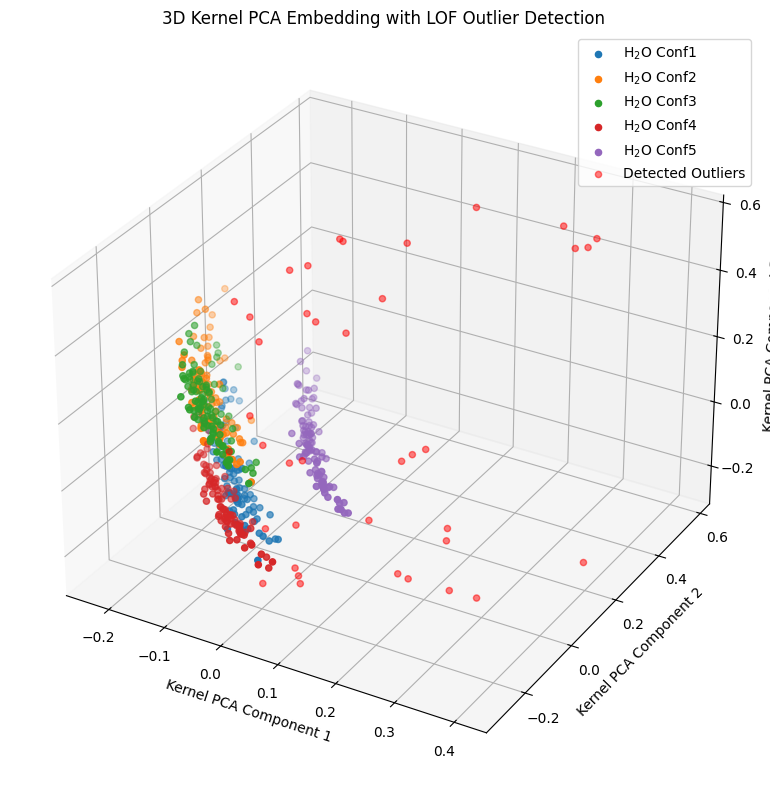

In [ ]:
# Try to eliminate the outliers using LocalOutlierFactor
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=n_components_90*2)
outlier_predictions = lof.fit_predict(embedding_kpca_all[:, :n_components_90])
# Get the indices of the inliers and outliers
inlier_indices = np.where(outlier_predictions == 1)[0]
outlier_indices = np.where(outlier_predictions == -1)[0]
print(f"Number of inliers detected: {len(inlier_indices)}")
print(f"Number of outliers detected: {len(outlier_indices)}")
# Plot the inliers and outliers in the embedding space
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Plot inliers
for j, label in enumerate(structure_labels):   
    indices = [idx for idx in inlier_indices if all_labels[idx] == label]
    ax.scatter(embedding_kpca_all[indices, 0], embedding_kpca_all[indices, 1], embedding_kpca_all[indices, 2], label=label)
# Plot outliers
ax.scatter(embedding_kpca_all[outlier_indices, 0], embedding_kpca_all[outlier_indices, 1], embedding_kpca_all[outlier_indices, 2], label="Detected Outliers", color='red', alpha=0.5)
ax.set_xlabel("Kernel PCA Component 1")
ax.set_ylabel("Kernel PCA Component 2")
ax.set_zlabel("Kernel PCA Component 3")
ax.set_title("3D Kernel PCA Embedding with LOF Outlier Detection")
ax.legend(loc='best')
ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Estimation of eps parameter for DBScan using K-Nearest Neighbors
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors

def find_optimal_eps(data, min_pts):
    neighbors = NearestNeighbors(n_neighbors=min_pts)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)

    # Sort the distances take thr last column
    sorted_distances = np.sort(distances[:, -1], axis=0)   
    i = np.arange(len(sorted_distances))
    knee_locator = KneeLocator(i, sorted_distances, curve='convex', direction='increasing')
    optimal_eps = sorted_distances[knee_locator.knee]
    return optimal_eps, sorted_distances, knee_locator
min_pts = n_components_90 * 2
optimal_eps, sorted_distances, knee_locator = find_optimal_eps(embedding_kpca_all, min_pts)
print(f"Optimal eps for DBScan: {optimal_eps}")

Optimal eps for DBScan: 0.1491632187340641


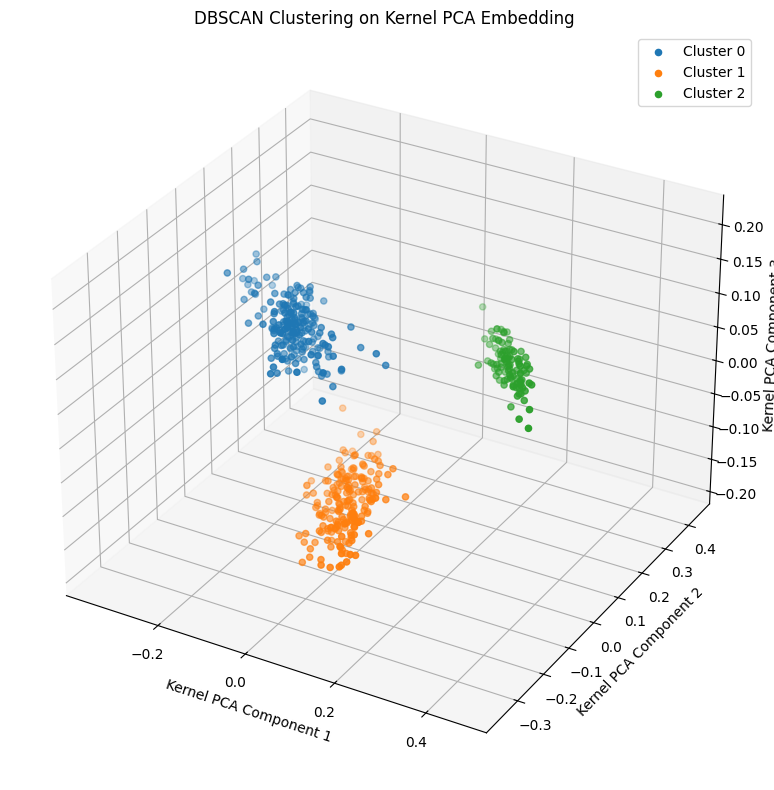

In [ ]:
# Now aplly density based clustering (DBSCAN) to the embedding to see if it can separate the outliers from the main clusters
from sklearn.cluster import DBSCAN
# All the retained components to see if it can separate the outliers better
embedding_kpca_all_retained = embedding_kpca_all[:, :n_components_90]
dbscan = DBSCAN(eps=optimal_eps, min_samples=2*n_components_90) # min_samples is set to 2 times the number of dimensions to account for the increased dimensionality
clusters = dbscan.fit_predict(embedding_kpca_all_retained)
# Plot the clusters in the 3D embedding space
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
unique_clusters = np.unique(clusters)
for cluster in unique_clusters:
    cluster_indices = np.where(clusters == cluster)[0]
    if cluster == -1:
        # Plot outliers in red
        ax.scatter(embedding_kpca_all_retained[cluster_indices, 0], embedding_kpca_all_retained[cluster_indices, 1], embedding_kpca_all_retained[cluster_indices, 2], label="DBSCAN Outliers", color='red', alpha=0.5)
    else:
        ax.scatter(embedding_kpca_all_retained[cluster_indices, 0], embedding_kpca_all_retained[cluster_indices, 1], embedding_kpca_all_retained[cluster_indices, 2], label=f"Cluster {cluster}")
ax.set_xlabel("Kernel PCA Component 1")
ax.set_ylabel("Kernel PCA Component 2")
ax.set_zlabel("Kernel PCA Component 3")
ax.set_title("DBSCAN Clustering on Kernel PCA Embedding")
ax.legend(loc='best')
ax.grid()
plt.tight_layout()
plt.show()

# Compare obtained clusters with true labels to see how well DBSCAN separated the outliers